In [1]:
import numpy as np
from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.svm import SVR
from sklearn.neighbors import KNeighborsRegressor
from sklearn.neural_network import MLPRegressor
from sklearn.model_selection import cross_val_score
from biom import load_table
import pandas as pd
import numpy as np
from biom import load_table
from sklearn.decomposition import PCA, SparsePCA, IncrementalPCA
from sklearn.model_selection import train_test_split, StratifiedKFold, KFold
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import r2_score, mean_absolute_error
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader, TensorDataset, SubsetRandomSampler, Subset
from torch import optim
from TRPCA import trpca, utils
import seaborn as sns
import matplotlib.pyplot as plt
%matplotlib inline
from tqdm.notebook import tqdm
import gc
from scipy.stats import ttest_ind
from itertools import combinations
from sklearn.model_selection import GroupKFold, StratifiedGroupKFold
import torch.nn.functional as F
import numpy as np
import matplotlib.pyplot as plt
import scipy.stats as stats
import numpy as np
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
from sklearn.preprocessing import LabelEncoder

def diagnose_regression(predictions, true_values):
    """
    Function to diagnose regression model performance.
    
    Args:
    predictions (array): Predicted values from the regression model.
    true_values (array): Actual values.
    
    Outputs:
    Displays residual plot, histogram of residuals, and Q-Q plot.
    Prints basic statistics of the residuals.
    """
    # Calculate residuals
    residuals = true_values - predictions
    
    # Residual Plot
    plt.figure(figsize=(12, 6))
    plt.subplot(1, 3, 1)
    plt.scatter(predictions, residuals, color='blue', alpha=0.5)
    plt.axhline(y=0, color='red', linestyle='--')
    plt.title('Residual Plot')
    plt.xlabel('Predicted Values')
    plt.ylabel('Residuals')
    plt.grid(True)
    
    # Histogram of Residuals
    plt.subplot(1, 3, 2)
    plt.hist(residuals, bins=30, color='blue', alpha=0.7)
    plt.title('Histogram of Residuals')
    plt.xlabel('Residuals')
    plt.ylabel('Frequency')
    plt.grid(True)
    
    # Q-Q Plot
    plt.subplot(1, 3, 3)
    stats.probplot(residuals, dist="norm", plot=plt)
    plt.title('Q-Q Plot')
    
    plt.tight_layout()
    plt.show()
    
    # Print residuals statistics
    print(f"Residuals Mean: {np.mean(residuals):.2f}")
    print(f"Residuals Standard Deviation: {np.std(residuals):.2f}")
    print(f"Residuals Min: {np.min(residuals):.2f}")
    print(f"Residuals Max: {np.max(residuals):.2f}")
    print(f"Residuals Median: {np.median(residuals):.2f}")
    print(f"Residuals Skewness: {stats.skew(residuals):.2f}")
    print(f"Residuals Kurtosis: {stats.kurtosis(residuals):.2f}")

In [2]:
# table = load_table('exploration_data/redbiom_human_metag_wolr2_table.biom').to_dataframe(dense=True).T.astype(int)
# taxonomy_table = pd.read_csv('data/WoLr2_metadata.tsv', sep='\t', index_col=0)
# age_metadata = pd.read_csv('exploration_data/redbiom_human_metag_wolr2_metadata.tsv', sep='\t', index_col=0)
# age_metadata = age_metadata.loc[age_metadata.qiita_study_id!=11405]
# age_metadata = age_metadata.loc[age_metadata.host_age_in_years>18]


# table = load_table('exploration_data/thdmi_5_country_unprocessed.biom').to_dataframe(dense=True).T.astype(int)
# age_metadata = pd.read_csv('exploration_data/64306_64306_analysis_mapping.txt', sep='\t', index_col=0)
# table = table.loc[age_metadata.index]

# mapping = {
#     'male': 'male',
#     'female': 'female',
#     '2': 'male',
#     '1': 'female',
#     'not provided': 'other',
#     'not applicable': 'other',
#     'other': 'other'
# }

# # Replace values
# age_metadata['sex'] = age_metadata['sex'].replace(mapping)
# age_metadata.thdmi_cohort = age_metadata.thdmi_cohort.fillna('unknown')

# mapping = {
#     'Diagnosed by an alternative medicine practitioner': 'True',
#     'diagnosed by a medical professional (doctor, physician assistant)': 'True',
#     'Diagnosed by a medical professional (doctor, physician assistant)': 'True',
#     'YES': 'True',
#     'I do not have this condition': 'False',
#     'i do not have this condition': 'False',
#     'NO': 'False',
#     'not applicable': 3,
#     'not provided': 3,
#     'Self-diagnosed': 3,
#     'self-diagnosed': 3,
#     float('nan'): 3  # NaN values
# }

# # Replace values
# age_metadata['diabetes'] = age_metadata['diabetes'].replace(mapping)
# age_metadata['thyroid'] = age_metadata['thyroid'].replace(mapping)
# age_metadata['ibs'] = age_metadata['ibs'].replace(mapping)
# age_metadata['ibd'] = age_metadata['ibd'].replace(mapping)

# mapping = {
#     'Omnivore': 'Omnivore',
#     'omnivore': 'Omnivore',
#     'Omnivore but do not eat red meat': 'Omnivore but do not eat red meat',
#     'omnivore but do not eat red meat': 'Omnivore but do not eat red meat',
#     'Vegetarian': 'Vegetarian',
#     'Vegetarian but eat seafood': 'Vegetarian but eat seafood',
#     'vegetarian but eat seafood': 'Vegetarian but eat seafood',
#     'Vegan': 'Vegan',
#     'not provided': 'unknown',
#     'not applicable': 'unknown',
#     float('nan'): 'unknown'  # NaN values
# }
# age_metadata['diet_type'] = age_metadata['diet_type'].replace(mapping)

In [3]:
# age_metadata.shape

In [4]:
# age_metadata.loc[age_metadata.keep_sample_for_thdmi=='yes'].shape, age_metadata.loc[age_metadata.sample_type=='Stool'].shape, age_metadata.loc[(age_metadata.keep_sample_for_thdmi=='yes')&(age_metadata.sample_type=='Stool')].shape

In [5]:
# age_metadata = age_metadata.loc[(age_metadata.keep_sample_for_thdmi=='yes')&(age_metadata.sex!='other')]
# # age_metadata = age_metadata.loc[(age_metadata.env_package=='human-gut')]
# age_metadata['host_age'] = pd.to_numeric(age_metadata.host_age_normalized_years, errors='coerce')
# age_metadata = age_metadata.loc[age_metadata.host_age.notna()]

In [6]:
# age_metadata = age_metadata.groupby('thdmi_cohort').sample(n=100, random_state=42)#age_metadata['thdmi_cohort'].value_counts().min()

In [7]:
# table = load_table('data/skin_1975.biom').to_dataframe(dense=True).T.astype(int)
# age_metadata = pd.read_csv('data/skin_1975_map.txt', sep='\t', index_col=0, dtype={'qiita_host_age':float})
# counts = age_metadata['host_subject_id'].value_counts()
# filtered_ids = counts[counts > 1].index
# age_metadata = age_metadata[age_metadata['host_subject_id'].isin(filtered_ids)]
# age_metadata = age_metadata.groupby('host_subject_id', group_keys=False).apply(lambda x: x.sample(n=1))

In [8]:
table = pd.read_csv('data/control.csv', index_col=0)
age_metadata = pd.read_csv('data/sampleMetadata.csv', index_col='sample_id', dtype={'age': float})
shared_index = table.index.intersection(age_metadata.loc[(age_metadata.age>18)&(age_metadata.age.notna())&(age_metadata.body_site=='stool')].index) #(age_metadata.age>18)&
table = table.loc[shared_index].drop(columns=['study_name','study_condition','subject_id'])
age_metadata = age_metadata.loc[shared_index]
countries_to_use = age_metadata.country.value_counts()[age_metadata.country.value_counts()>270].index.tolist()
age_metadata = age_metadata.loc[age_metadata.country.isin(countries_to_use)]
age_metadata = age_metadata.groupby('country').sample(n=270, random_state=42)

table = (table*1000).round().astype(int)

/var/folders/y9/wgj9mj_1555fbmw9d5qfq36m0000gn/T/ipykernel_80356/3318934685.py:2: DtypeWarning: Columns (21,22,25,28,29,30,32,33,35,38,51,52,53,54,55,56,57,58,63,64,65,67,68,69,74,75,76,80,90,91,92,93,96,104,105,108,109,111,112,116,117,118,119,120,121,126,128,129,134) have mixed types. Specify dtype option on import or set low_memory=False.
  age_metadata = pd.read_csv('data/sampleMetadata.csv', index_col='sample_id', dtype={'age': float})


In [9]:
age_metadata.country.value_counts()

country
CHN    270
GBR    270
JPN    270
NLD    270
USA    270
Name: count, dtype: int64

In [10]:
table = np.log(table.loc[age_metadata.index] + 1)
columns_to_drop = table.columns[table.apply(lambda col: (col != 0).sum()) < 0]# drop columns with low prev
table = table.drop(columns=columns_to_drop)
# table = (table - table.mean())/table.std()
# Assuming age_metadata is your DataFrame and 'thdmi_cohort' is the column you want to encode
dummies = pd.get_dummies(age_metadata[['country']])

# Convert dummy variables to a single column of class labels
label_encoder = LabelEncoder()
# Data preparation
X_np = table.to_numpy()
y_np = age_metadata.age.astype(float)
y2_np = age_metadata['country']#label_encoder.fit_transform(age_metadata['thdmi_cohort'])

# Apply PCA
# n_dimensions = 256
# pca = PCA(n_components=n_dimensions)
# X1_reduced = pca.fit_transform(age_table)
df = pd.DataFrame(table.values, index=table.index)
df['age'] = age_metadata.loc[age_metadata.index.isin(df.index)].age

In [11]:
df.shape

(1350, 2046)

In [12]:
# dummies = pd.get_dummies(age_metadata[['thdmi_cohort']])
# dummies = pd.get_dummies(age_metadata[['body_site', 'sex']])

In [13]:
# Parameters
num_folds = 5
batch_size = 512
epochs = 2000

# K-Fold Cross-Validator
# kf = GroupKFold(n_splits=num_folds)
kf = StratifiedGroupKFold(n_splits=num_folds)
# kf = StratifiedKFold(n_splits=num_folds)
# kf = KFold(n_splits=num_folds)
# Standardize features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df.drop(columns=['age']).to_numpy())
# Prepare full dataset (no split into train/test yet)
X = torch.tensor(df.drop(columns=['age']).to_numpy(), dtype=torch.float32)#torch.tensor(X_scaled, dtype=torch.float32)#df.drop(columns=['age']).to_numpy(), dtype=torch.float32)
y1 = torch.tensor(df.age.astype(float).to_numpy(), dtype=torch.float32).unsqueeze(1)
y2 = torch.tensor(dummies.to_numpy(), dtype=torch.float32)  # For binary classification, use long data type

dataset = TensorDataset(X, y1, y2)
subjects = age_metadata.subject_id
strata = age_metadata.country.astype(str)#+age_metadata.age_category.astype(str)
original_indices = age_metadata.index.tolist()

# Loss function, model instantiation, etc., outside the loop
regression_criterion = nn.L1Loss()
classification_criterion = nn.BCEWithLogitsLoss()#CrossEntropyLoss()

# Dictionary to store the test indices and their corresponding predictions and true values
test_predictions = {}
fold_performance = []

# Cross-validation starts add y=y for kf split y=strata for strata; , y=strata, groups=subjects for strat group.
for fold, (train_idx, val_idx) in enumerate(kf.split(dataset, y=strata, groups=subjects)):
    print(f'Fold {fold+1}/{num_folds}')
    train_subset = Subset(dataset, train_idx)
    val_subset = Subset(dataset, val_idx)

    # DataLoaders using the subsets directly
    train_loader = DataLoader(train_subset, batch_size=batch_size, shuffle=True)  # Shuffle here if needed
    val_loader = DataLoader(val_subset, batch_size=batch_size, shuffle=False)

    # Reinitialize the model for each fold
    regression_model = trpca.TransformerRegressionClassificationModel(feature_size=df.shape[1]-1, d_model=128, num_transformer_layers=3, nhead=8, num_classes=y2.shape[1], dim_feedforward=2048, dropout=0.2, fast_transformer=True)
    optimizer = optim.SGD(regression_model.parameters(), lr=0.001)#, weight_decay=0.1)
    scheduler = optim.lr_scheduler.CosineAnnealingWarmRestarts(optimizer, T_0=10, T_mult=2, eta_min=0)
    device = torch.device('cuda' if torch.cuda.is_available() else ('mps' if torch.backends.mps.is_available() else 'cpu'))
    regression_model.to(device)

    best_valid_loss = float('inf')  # Initialize the best validation loss for the fold
    best_train_loss_at_best_val = None  # Track training loss when best validation loss occurs

    # Training and validation loop
    for epoch in tqdm(range(epochs), total=len(range(epochs))):
        # Training Phase
        regression_model.train()
        train_loss = 0
        for batch_features, batch_regression_labels, batch_classification_labels in train_loader:
            batch_features, batch_regression_labels, batch_classification_labels = batch_features.to(device), batch_regression_labels.to(device), batch_classification_labels.to(device)
            optimizer.zero_grad()
            outputs = regression_model(batch_features)
            regression_loss = regression_criterion(outputs['regression_output'], batch_regression_labels)
            classification_loss = classification_criterion(outputs['classification_output'], batch_classification_labels)
            loss = regression_loss + 10*classification_loss
            loss.backward()
            optimizer.step()
            train_loss += loss.item() * batch_features.size(0)

        train_loss /= len(train_idx)

        # Validation Phase
        regression_model.eval()
        valid_loss = 0
        with torch.no_grad():
            for batch_features, batch_regression_labels, batch_classification_labels in val_loader:
                batch_features, batch_regression_labels, batch_classification_labels = batch_features.to(device), batch_regression_labels.to(device), batch_classification_labels.to(device)
                outputs = regression_model(batch_features)
                regression_loss = regression_criterion(outputs['regression_output'], batch_regression_labels)
                classification_loss = classification_criterion(outputs['classification_output'], batch_classification_labels)
                loss = regression_loss + 10*classification_loss
                valid_loss += loss.item() * batch_features.size(0)

        valid_loss /= len(val_idx)

        # Epoch ends
        print(f'Epoch {epoch+1}/{epochs}, Train Loss: {train_loss:.4f}, Val Loss: {valid_loss:.4f}')
        scheduler.step()
        # At the end of each epoch, evaluate on validation set
        if valid_loss < best_valid_loss:
            best_valid_loss = valid_loss
            best_train_loss_at_best_val = train_loss

            # Save predictions for this fold
            all_regression_preds = []
            all_classification_preds = []
            all_y_true_regression = []
            all_y_true_classification = []
            with torch.no_grad():
                for batch_features, batch_regression_labels, batch_classification_labels in val_loader:
                    batch_features, batch_regression_labels, batch_classification_labels = batch_features.to(device), batch_regression_labels.to(device), batch_classification_labels.to(device)
                    outputs = regression_model(batch_features)
                    all_regression_preds.extend(outputs['regression_output'].cpu().numpy())
                    all_classification_preds.extend(outputs['classification_output'].cpu().numpy())
                    all_y_true_regression.extend(batch_regression_labels.cpu().numpy())
                    all_y_true_classification.extend(batch_classification_labels.cpu().numpy())

            # Update test predictions dictionary
            original_val_indices = [original_indices[i] for i in val_idx]
            test_predictions.update({orig_idx: (reg_pred, reg_true, cls_pred, cls_true) for orig_idx, reg_pred, reg_true, cls_pred, cls_true in zip(original_val_indices, all_regression_preds, all_y_true_regression, all_classification_preds, all_y_true_classification)})
        # if best_valid_loss<1.6:
        #     break
    # Store the best validation loss of this fold and its associated training loss
    print(f"Best loss: {best_valid_loss}")  
    fold_performance.append((best_train_loss_at_best_val, best_valid_loss))
    del regression_model, optimizer, scheduler, train_loader, val_loader
    torch.mps.empty_cache()
    gc.collect()

# Finalize cross-validation
print("K-Fold Cross-Validation completed.")
print("Best training and validation losses for each fold:", fold_performance)

### Step 2: Plot the Predictions

# Extract the indices and predictions
indices = list(test_predictions.keys())
regression_predictions = [test_predictions[idx][0] for idx in indices]
regression_true_values = [test_predictions[idx][1] for idx in indices]
classification_predictions = [test_predictions[idx][2] for idx in indices]
classification_true_values = [test_predictions[idx][3] for idx in indices]

Fold 1/5


  0%|          | 0/2000 [00:00<?, ?it/s]

Epoch 1/2000, Train Loss: 54.5480, Val Loss: 55.7915
Epoch 2/2000, Train Loss: 54.1570, Val Loss: 55.3243
Epoch 3/2000, Train Loss: 53.7129, Val Loss: 54.8725
Epoch 4/2000, Train Loss: 53.2924, Val Loss: 54.5283
Epoch 5/2000, Train Loss: 52.9752, Val Loss: 54.3087
Epoch 6/2000, Train Loss: 52.7693, Val Loss: 54.1815
Epoch 7/2000, Train Loss: 52.6491, Val Loss: 54.1115
Epoch 8/2000, Train Loss: 52.5828, Val Loss: 54.0744
Epoch 9/2000, Train Loss: 52.5461, Val Loss: 54.0587
Epoch 10/2000, Train Loss: 52.5310, Val Loss: 54.0547
Epoch 11/2000, Train Loss: 52.4960, Val Loss: 53.9185
Epoch 12/2000, Train Loss: 52.3527, Val Loss: 53.7995
Epoch 13/2000, Train Loss: 52.2288, Val Loss: 53.6740
Epoch 14/2000, Train Loss: 52.0970, Val Loss: 53.5256
Epoch 15/2000, Train Loss: 51.9438, Val Loss: 53.3348
Epoch 16/2000, Train Loss: 51.7524, Val Loss: 53.0921
Epoch 17/2000, Train Loss: 51.5066, Val Loss: 52.7732
Epoch 18/2000, Train Loss: 51.1866, Val Loss: 52.3394
Epoch 19/2000, Train Loss: 50.7482, V

  0%|          | 0/2000 [00:00<?, ?it/s]

Epoch 1/2000, Train Loss: 54.7457, Val Loss: 55.4029
Epoch 2/2000, Train Loss: 54.4648, Val Loss: 55.1196
Epoch 3/2000, Train Loss: 54.1412, Val Loss: 54.6898
Epoch 4/2000, Train Loss: 53.7390, Val Loss: 54.2975
Epoch 5/2000, Train Loss: 53.3767, Val Loss: 54.0113
Epoch 6/2000, Train Loss: 53.1144, Val Loss: 53.8341
Epoch 7/2000, Train Loss: 52.9515, Val Loss: 53.7347
Epoch 8/2000, Train Loss: 52.8563, Val Loss: 53.6834
Epoch 9/2000, Train Loss: 52.8114, Val Loss: 53.6613
Epoch 10/2000, Train Loss: 52.7879, Val Loss: 53.6559
Epoch 11/2000, Train Loss: 52.7394, Val Loss: 53.4758
Epoch 12/2000, Train Loss: 52.5576, Val Loss: 53.3439
Epoch 13/2000, Train Loss: 52.4155, Val Loss: 53.2131
Epoch 14/2000, Train Loss: 52.2784, Val Loss: 53.0639
Epoch 15/2000, Train Loss: 52.1250, Val Loss: 52.8760
Epoch 16/2000, Train Loss: 51.9352, Val Loss: 52.6292
Epoch 17/2000, Train Loss: 51.6872, Val Loss: 52.3076
Epoch 18/2000, Train Loss: 51.3674, Val Loss: 51.8730
Epoch 19/2000, Train Loss: 50.9296, V

...

Epoch 1/2000, Train Loss: 55.1869, Val Loss: 52.8852
Epoch 2/2000, Train Loss: 54.6726, Val Loss: 52.3123
Epoch 3/2000, Train Loss: 54.1369, Val Loss: 51.8380
Epoch 4/2000, Train Loss: 53.6989, Val Loss: 51.5374
Epoch 5/2000, Train Loss: 53.4205, Val Loss: 51.3718
Epoch 6/2000, Train Loss: 53.2622, Val Loss: 51.2800
Epoch 7/2000, Train Loss: 53.1700, Val Loss: 51.2263
Epoch 8/2000, Train Loss: 53.1158, Val Loss: 51.1981
Epoch 9/2000, Train Loss: 53.0884, Val Loss: 51.1852
Epoch 10/2000, Train Loss: 53.0776, Val Loss: 51.1820
Epoch 11/2000, Train Loss: 53.0457, Val Loss: 51.0585
Epoch 12/2000, Train Loss: 52.9141, Val Loss: 50.9269
Epoch 13/2000, Train Loss: 52.7740, Val Loss: 50.7617
Epoch 14/2000, Train Loss: 52.6055, Val Loss: 50.5467
Epoch 15/2000, Train Loss: 52.3833, Val Loss: 50.2515
Epoch 16/2000, Train Loss: 52.0854, Val Loss: 49.8349
Epoch 17/2000, Train Loss: 51.6555, Val Loss: 49.2186
Epoch 18/2000, Train Loss: 51.0209, Val Loss: 48.2422
Epoch 19/2000, Train Loss: 49.9952, V

  0%|          | 0/2000 [00:00<?, ?it/s]

Epoch 1/2000, Train Loss: 55.2287, Val Loss: 53.5943
Epoch 2/2000, Train Loss: 54.8934, Val Loss: 53.1782
Epoch 3/2000, Train Loss: 54.4897, Val Loss: 52.7141
Epoch 4/2000, Train Loss: 54.0554, Val Loss: 52.3214
Epoch 5/2000, Train Loss: 53.6945, Val Loss: 52.0569
Epoch 6/2000, Train Loss: 53.4543, Val Loss: 51.9010
Epoch 7/2000, Train Loss: 53.3053, Val Loss: 51.8144
Epoch 8/2000, Train Loss: 53.2225, Val Loss: 51.7699
Epoch 9/2000, Train Loss: 53.1797, Val Loss: 51.7507
Epoch 10/2000, Train Loss: 53.1611, Val Loss: 51.7460
Epoch 11/2000, Train Loss: 53.1212, Val Loss: 51.5872
Epoch 12/2000, Train Loss: 52.9556, Val Loss: 51.4690
Epoch 13/2000, Train Loss: 52.8288, Val Loss: 51.3485
Epoch 14/2000, Train Loss: 52.7023, Val Loss: 51.2041
Epoch 15/2000, Train Loss: 52.5533, Val Loss: 51.0244
Epoch 16/2000, Train Loss: 52.3723, Val Loss: 50.7943
Epoch 17/2000, Train Loss: 52.1402, Val Loss: 50.4936
Epoch 18/2000, Train Loss: 51.8406, Val Loss: 50.0909
Epoch 19/2000, Train Loss: 51.4373, V

  0%|          | 0/2000 [00:00<?, ?it/s]

Epoch 1/2000, Train Loss: 54.6964, Val Loss: 55.0432
Epoch 2/2000, Train Loss: 54.3647, Val Loss: 54.7251
Epoch 3/2000, Train Loss: 54.0006, Val Loss: 54.2789
Epoch 4/2000, Train Loss: 53.5850, Val Loss: 53.9165
Epoch 5/2000, Train Loss: 53.2478, Val Loss: 53.6749
Epoch 6/2000, Train Loss: 53.0266, Val Loss: 53.5298
Epoch 7/2000, Train Loss: 52.8911, Val Loss: 53.4481
Epoch 8/2000, Train Loss: 52.8150, Val Loss: 53.4059
Epoch 9/2000, Train Loss: 52.7708, Val Loss: 53.3877
Epoch 10/2000, Train Loss: 52.7566, Val Loss: 53.3832
Epoch 11/2000, Train Loss: 52.7192, Val Loss: 53.2322
Epoch 12/2000, Train Loss: 52.5623, Val Loss: 53.1149
Epoch 13/2000, Train Loss: 52.4379, Val Loss: 52.9992
Epoch 14/2000, Train Loss: 52.3214, Val Loss: 52.8689
Epoch 15/2000, Train Loss: 52.1864, Val Loss: 52.7090
Epoch 16/2000, Train Loss: 52.0241, Val Loss: 52.5107
Epoch 17/2000, Train Loss: 51.8252, Val Loss: 52.2636
Epoch 18/2000, Train Loss: 51.5743, Val Loss: 51.9481
Epoch 19/2000, Train Loss: 51.2615, V

In [14]:
# Sample data setup (replace with actual data)
classification_true_values = np.array(classification_true_values)
classification_predictions = np.vstack(classification_predictions)

# Convert logits to probabilities using the sigmoid function
classification_predictions_probs = 1 / (1 + np.exp(-classification_predictions))

# Convert probabilities to binary labels using a threshold of 0.5
classification_predictions_binary = (classification_predictions_probs > 0.5).astype(int)

# Calculate metrics
accuracy = accuracy_score(classification_true_values.flatten(), classification_predictions_binary.flatten())
precision = precision_score(classification_true_values, classification_predictions_binary, average='samples')
recall = recall_score(classification_true_values, classification_predictions_binary, average='samples')
f1 = f1_score(classification_true_values, classification_predictions_binary, average='samples')

print(f'Classification Accuracy: {accuracy:.4f}')
print(f'Classification Precision: {precision:.4f}')
print(f'Classification Recall: {recall:.4f}')
print(f'Classification F1-Score: {f1:.4f}')

Classification Accuracy: 0.9281
Classification Precision: 0.7985
Classification Recall: 0.8185
Classification F1-Score: 0.8052


/Users/tylermyers/anaconda3/envs/transformers/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1469: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in samples with no predicted labels. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))


In [15]:
dummies

,country_CHN,country_GBR,country_JPN,country_NLD,country_USA
HV-10,True,False,False,False,False
wHAXPI033788-13,True,False,False,False,False
HD-50,True,False,False,False,False
SZAXPI015240-26,True,False,False,False,False
YEZ_N-43,True,False,False,False,False
...,...,...,...,...,...
SRS016203,False,False,False,False,True
HMP2_J43817_M_ST_T0_B0_0120_ZYLJ7R7-4012_C93B2ANXX,False,False,False,False,True
ESS-0364,False,False,False,False,True
MMRS38861560ST-27-0-0,False,False,False,False,True


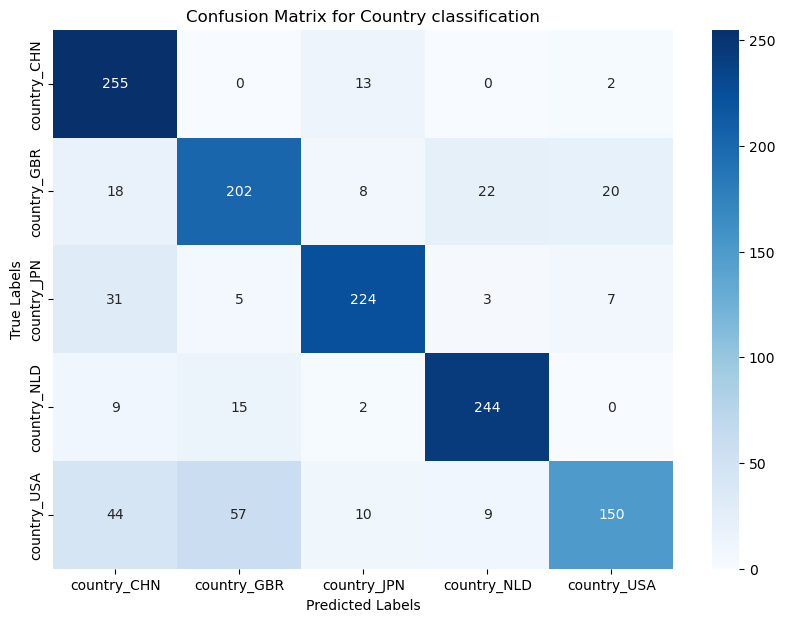

In [16]:
import numpy as np
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

# Separate the columns for the two tasks
true_values_task1 = classification_true_values[:, :dummies.shape[1]]
predictions_task1 = classification_predictions_binary[:, :dummies.shape[1]]

# true_values_task2 = classification_true_values[:, 5:]
# predictions_task2 = classification_predictions_binary[:, 5:]

# true_values_task3 = classification_true_values[:, 5:]
# predictions_task3 = classification_predictions_binary[:, 5:]

# Flatten the arrays for confusion matrix calculation
true_labels_task1 = true_values_task1.argmax(axis=1)
pred_labels_task1 = predictions_task1.argmax(axis=1)

# true_labels_task2 = true_values_task2.argmax(axis=1)
# pred_labels_task2 = predictions_task2.argmax(axis=1)

# true_labels_task3 = true_values_task3.argmax(axis=1)
# pred_labels_task3 = predictions_task3.argmax(axis=1)

# Calculate the confusion matrices
conf_matrix_task1 = confusion_matrix(true_labels_task1, pred_labels_task1)
# conf_matrix_task2 = confusion_matrix(true_labels_task2, pred_labels_task2)
# conf_matrix_task3 = confusion_matrix(true_labels_task3, pred_labels_task3)

# Custom labels for the confusion matrices
# labels_task1 = ['16S', 'WGS']
labels_task1 = dummies.columns#['Japan', 'Mexico', 'Spain', 'UK', 'US']
labels_task2 = ['Female', 'Male']

# Plot confusion matrix for Task 1
plt.figure(figsize=(10, 7))
sns.heatmap(conf_matrix_task1, annot=True, fmt='d', cmap='Blues', xticklabels=labels_task1, yticklabels=labels_task1)
plt.xlabel('Predicted Labels')
plt.ylabel('True Labels')
plt.title('Confusion Matrix for Country classification')
plt.show()

# # Plot confusion matrix for Task 2
# plt.figure(figsize=(10, 7))
# sns.heatmap(conf_matrix_task2, annot=True, fmt='d', cmap='Blues', xticklabels=labels_task2, yticklabels=labels_task2)
# plt.xlabel('Predicted Labels')
# plt.ylabel('True Labels')
# plt.title('Confusion Matrix for Host Sex classification')
# plt.show()

# # Plot confusion matrix for Task 2
# plt.figure(figsize=(10, 7))
# sns.heatmap(conf_matrix_task3, annot=True, fmt='d', cmap='Blues', xticklabels=labels_task3, yticklabels=labels_task3)
# plt.xlabel('Predicted Labels')
# plt.ylabel('True Labels')
# plt.title('Confusion Matrix for Sex classification')
# plt.show()

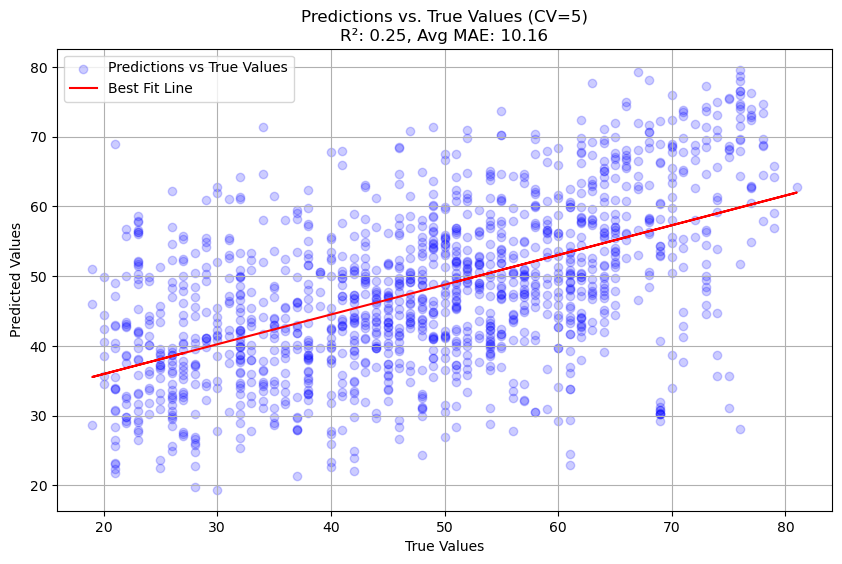

In [17]:
predictions = np.array(regression_predictions)
true_values = np.array(regression_true_values)

# Calculate R² and MAE
r2 = r2_score(true_values, predictions)
mae = mean_absolute_error(true_values, predictions)

# Calculate coefficients for the best fit line
slope, intercept = np.polyfit(true_values.reshape(-1), predictions.reshape(-1), 1)
best_fit_line = slope * true_values + intercept

plt.figure(figsize=(10, 6))
plt.scatter(true_values, predictions, color='blue', alpha=0.2, label='Predictions vs True Values')
plt.plot(true_values, best_fit_line, color='red', label='Best Fit Line')  # Plotting the best fit line
plt.title(f'Predictions vs. True Values (CV=5)\nR²: {r2:.2f}, Avg MAE: {mae:.2f}')
plt.ylabel('Predicted Values')
plt.xlabel('True Values')
plt.legend()
plt.grid(True)# Optional: Adds grid for better visualization
plt.show()

In [18]:
# List of regressors to compare
regressors = {
    "Support Vector Regression": SVR(kernel='rbf', C=1.0, epsilon=0.1),
    "Gradient Boosting Regression": GradientBoostingRegressor(n_estimators=100, random_state=42),
    "K-Neighbors Regression": KNeighborsRegressor(n_neighbors=5),
    # "Neural Network Regression": MLPRegressor(hidden_layer_sizes=(100,), activation='relu', solver='adam', max_iter=1000, random_state=42),
    "Random Forest Regression": RandomForestRegressor(n_estimators=100, random_state=42),
}

In [19]:
# Evaluate each regressor using cross-validation with GroupKFold
for name, regressor in regressors.items():
    cv_scores = cross_val_score(regressor, X_np, y_np, cv=5, scoring='neg_mean_absolute_error')
    print(f"{name} - Cross-Validation Scores (Negative MAE): {cv_scores}")
    print(f"{name} - Mean CV Score: {cv_scores.mean()} +/- {cv_scores.std()}\n")

Support Vector Regression - Cross-Validation Scores (Negative MAE): [-13.20009313  -9.48381626 -17.45559446 -12.19223764 -14.16392291]
Support Vector Regression - Mean CV Score: -13.299132880986775 +/- 2.60060383269312

Gradient Boosting Regression - Cross-Validation Scores (Negative MAE): [-11.88423975  -9.36600022 -15.99812642 -11.10689183 -14.12836417]
Gradient Boosting Regression - Mean CV Score: -12.496724475117896 +/- 2.3250922720803633

K-Neighbors Regression - Cross-Validation Scores (Negative MAE): [-13.07481481 -11.06814815 -23.03555556 -11.5962963  -14.21703704]
K-Neighbors Regression - Mean CV Score: -14.59837037037037 +/- 4.361826410474929

Random Forest Regression - Cross-Validation Scores (Negative MAE): [-11.66281481  -9.2632963  -16.11137037 -11.29077778 -14.05759259]
Random Forest Regression - Mean CV Score: -12.47717037037037 +/- 2.3708577755370355



In [20]:
from sklearn.svm import SVC
from sklearn.ensemble import GradientBoostingClassifier, RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.model_selection import cross_val_score
from sklearn.metrics import accuracy_score

# List of classifiers to compare
classifiers = {
    "Support Vector Classification": SVC(kernel='rbf', C=1.0),
    "Gradient Boosting Classification": GradientBoostingClassifier(n_estimators=100, random_state=42),
    "K-Neighbors Classification": KNeighborsClassifier(n_neighbors=5),
    "Neural Network Classification": MLPClassifier(hidden_layer_sizes=(100,), activation='relu', solver='adam', max_iter=1000, random_state=42),
    "Random Forest Classification": RandomForestClassifier(n_estimators=100, random_state=42),
}

# Evaluate each classifier using cross-validation
for name, classifier in classifiers.items():
    cv_scores = cross_val_score(classifier, X_np, y2_np, cv=5, scoring='accuracy')
    print(f"{name} - Cross-Validation Scores (Accuracy): {cv_scores}")
    print(f"{name} - Mean CV Score: {cv_scores.mean()} +/- {cv_scores.std()}\n")

Support Vector Classification - Cross-Validation Scores (Accuracy): [0.89259259 0.85925926 0.85925926 0.88518519 0.88148148]
Support Vector Classification - Mean CV Score: 0.8755555555555556 +/- 0.013778574250176498

Gradient Boosting Classification - Cross-Validation Scores (Accuracy): [0.91481481 0.87407407 0.81851852 0.86666667 0.87407407]
Gradient Boosting Classification - Mean CV Score: 0.8696296296296296 +/- 0.030667024510347342

K-Neighbors Classification - Cross-Validation Scores (Accuracy): [0.71111111 0.70740741 0.68888889 0.74074074 0.73333333]
K-Neighbors Classification - Mean CV Score: 0.7162962962962963 +/- 0.018680770685805155

Neural Network Classification - Cross-Validation Scores (Accuracy): [0.9037037  0.8962963  0.86666667 0.90740741 0.88148148]
Neural Network Classification - Mean CV Score: 0.8911111111111112 +/- 0.015108205966200827

Random Forest Classification - Cross-Validation Scores (Accuracy): [0.88148148 0.82592593 0.81481481 0.88148148 0.82592593]
Random F